# Fraud Detection System for Mobile-Money Transactions: PaySim Dataset

**The problem.** Fraud detection on mobile money is a class-imbalance problem
before it is anything else. In PaySim, 8,213 of 6,362,620 transactions are
fraudulent, so a model that predicts "not fraud" for everything is 99.87%
accurate and catches nothing. Everything below follows from that: the metric,
the threshold, the features, and what counts as evidence that any of it worked.

Scoring here is batch, over a CSV. Nothing in this notebook is real-time
inference; streaming is an open item on the README's roadmap rather than
something built.

**How this notebook is organised.** It follows the three stages of a
model-building project, each broken into small numbered tasks:

- **Part 1, prepare the data** (sections 1 to 8): load PaySim, explore it,
  clean it, handle hidden missing values, engineer the balance-discrepancy
  features, and split it by time.
- **Part 2, build and evaluate the models** (sections 9 to 13): a baseline
  rule first, then five models, then the operating point, calibration, feature
  importance, the cost trade-off, a SMOTE ablation and SHAP explanations.
- **Part 3, communicate the results** (sections 14 and 15): the champion, what
  the notebook found, its limitations, and how it relates to the shipped
  pipeline in `src/`.

Each task is one short code cell. Cells marked **Check your work** contain
assertions, so the notebook stops at the step that went wrong instead of
carrying a wrong number forward.

## How to reproduce this notebook

**Data.** PaySim 1, from [Kaggle](https://www.kaggle.com/datasets/ealaxi/paysim1):
6,362,620 simulated mobile-money transactions over 743 hourly steps, of which
8,213 are fraudulent (0.129%). The CSV is 470MB, is not ours to redistribute, and
is gitignored. Download it and either put
`PS_20174392719_1491204439457_log.csv` next to this notebook or point the
`PAYSIM_CSV` environment variable at it. The loading cell raises a clear error if
it finds neither, rather than quietly falling back to a sample and reporting
numbers from data you cannot identify.

**Environment.** `pip install -r requirements.txt`, which pins every library to the
exact version this notebook was executed with (`requirements-lock.txt` pins the
full dependency tree). Nothing is installed from inside the notebook. Task 1.2
prints the version of every library the results depend on, so the stack that
produced a number is recorded next to it.

**Determinism.** One seed, `CONFIG["random_seed"]`, set once. Every model that
takes a `random_state` is given it. XGBoost and LightGBM with fixed seeds and
fixed thread counts are reproducible to the bit on the same machine; across
machines expect agreement to about four decimal places.

**Runtime.** The stored run took 89 minutes end to end on a 16 GB laptop with about 5 GB free, dominated by the
stacking ensemble (which fits three base models three times over) and the SMOTE ablation. The strip plots draw
every fraud and a fixed 200,000-row sample of genuine transactions. Nothing here needs a GPU.

**What this notebook is, and is not.** This is the exploration: the reasoning,
the dead ends, the ablations, and the charts that justify each decision. The
production path is `src/`, which is tested and runs from the command line. Where
the two differ, the difference is deliberate and listed in section 15. `src/` is
the authority for the numbers quoted in the README.

### Provenance of the outputs stored in this file

The outputs below come from a full top-to-bottom run of this notebook that finished on 4 October 2026, on the
exact library versions pinned in `requirements.txt` and printed by Task 1.2. The run took 89 minutes on a
16 GB laptop shared with other jobs.

**What changed since the previous stored run (3 October 2026).** The notebook was reorganised into small
numbered tasks: long cells were split, explanatory comments moved into the text, the baseline rule is now
scored before the models, and check-your-work assertions were added after the load, the cleaning, the
missing-value handling and the split. No computation changed, and every figure is the same as in the previous
run. The only new output is the hourly fraud table of Task 3.9, which the earlier version computed without
displaying.

This notebook is the exploratory comparison. The shipped model, and every number in the README, come from
`src/` (35 trees, tuned class weight 2.14, engineered balance features), which reports holdout PR-AUC 0.9984
and walk-forward PR-AUC 0.9971 plus or minus 0.0020, and is covered by the tests in `tests/`.

---
# Part 1: Prepare the data

## 1. Setup

**Task 1.1:** Import the libraries. Every library is pinned to an exact version
in `requirements.txt`; nothing is installed from inside the notebook.

In [1]:
import gc
import logging
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12
pd.options.display.float_format = "{:,.4f}".format

# Library loggers stay at WARNING so their notices do not print into the outputs;
# this notebook's own logger reports at INFO.
logging.basicConfig(level=logging.WARNING, format="%(levelname)s | %(message)s")
log = logging.getLogger("fraud_notebook")
log.setLevel(logging.INFO)

Then the modelling and evaluation tools: five model families, SMOTE for the
resampling test, and the metrics.

In [2]:
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# shap imports tqdm, which warns when ipywidgets is not installed (progress bars only)
warnings.filterwarnings("ignore", message="IProgress not found")
import shap  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

**Task 1.2:** Record the library versions that produced every output below.

In [3]:
import imblearn  # noqa: E402
import lightgbm  # noqa: E402
import sklearn  # noqa: E402
import xgboost  # noqa: E402

print("Library versions for this run")
print(f"  python            {sys.version.split()[0]}")
print(f"  numpy             {np.__version__}")
print(f"  pandas            {pd.__version__}")
print(f"  scikit-learn      {sklearn.__version__}")
print(f"  xgboost           {xgboost.__version__}")
print(f"  lightgbm          {lightgbm.__version__}")
print(f"  imbalanced-learn  {imblearn.__version__}")
print(f"  shap              {shap.__version__}")

Library versions for this run
  python            3.13.9
  numpy             2.4.6
  pandas            3.0.3
  scikit-learn      1.8.0
  xgboost           3.3.0
  lightgbm          4.6.0
  imbalanced-learn  0.14.2
  shap              0.51.0


**Task 1.3:** Put every setting in one place.

- `data_path`: the PaySim CSV, next to the notebook by default, or wherever
  `PAYSIM_CSV` points.
- `split_step`: the time split. Train on hours 1 to 490, test on 491 to 743.
  It is a step number, not a share of rows: step 490 is about 66% of the time
  horizon but about 95% of the rows, because volume is not uniform across the
  month. Section 8 explains why the split is by time.
- `fn_fp_cost_ratio`: in the cost sweep of section 12, each missed fraud costs
  as much as this many false alarms. The shipped pipeline uses 100:1; 10:1 is
  swept here as the conservative end. The point of the sweep is that the
  threshold moves with the ratio, so the ratio has to come from the operator's
  own economics.
- `shap_sample_n`: rows sampled for the SHAP charts (speed against precision).

In [4]:
CONFIG = {
    "data_path": os.environ.get("PAYSIM_CSV", "PS_20174392719_1491204439457_log.csv"),
    "random_seed": 42,
    "split_step": 490,            # train on steps 1-490, test on 491-743
    "fn_fp_cost_ratio": 10,       # one missed fraud costs as much as 10 false alarms
    "shap_sample_n": 2_000,
}

np.random.seed(CONFIG["random_seed"])  # one seed for every stochastic step below
log.info("CONFIG loaded: %d parameters set", len(CONFIG))

INFO | CONFIG loaded: 5 parameters set


**Task 1.4:** Set the thread budget. `n_jobs=-1` would ask for every core, and
scikit-learn's stacking ensemble nests that: it parallelises over base models,
each of which parallelises internally, across three folds, and each worker
copies a 2.6-million-row frame. On a 16 GB machine that is the difference
between finishing and being killed by the operating system. No model here uses
row or column subsampling, so the fitted trees are identical at any thread
count; this only changes peak memory.

Random forests are the exception: their trees share one copy of the data, so
extra threads cost little memory, and a seeded forest is identical at any
thread count. At one thread the forest alone would run for hours.

In [5]:
N_JOBS = 1    # threads for XGBoost, LightGBM and the stacking ensemble
RF_JOBS = 4   # threads for random forests

---
## 2. Import

PaySim simulates mobile-money transactions based on real transaction logs from
an African country: about 6.3 million transactions of five types, CASH_IN,
CASH_OUT, DEBIT, PAYMENT and TRANSFER.

**Task 2.1:** Find the CSV, and fail with instructions if it is not there.

In [6]:
data_path = Path(CONFIG["data_path"])
if not data_path.exists():
    raise FileNotFoundError(
        "PaySim CSV not found at: " + str(data_path.resolve())
        + "\n\nThe file is 470MB and is not redistributable, so it is gitignored."
        + "\nDownload 'PaySim 1' from https://www.kaggle.com/datasets/ealaxi/paysim1"
        + "\nand either place PS_20174392719_1491204439457_log.csv next to this"
        + "\nnotebook, or point the PAYSIM_CSV environment variable at it."
    )

**Task 2.2:** Load it and rename the balance columns. PaySim's own names are
inconsistently capitalised (`oldbalanceOrg` has no "i", `newbalanceOrig` does),
which invites typos. The notebook renames them to consistent camelCase. The
shipped pipeline in `src/` keeps PaySim's raw names on purpose, so that a file
downloaded from Kaggle needs no pre-processing.

In [7]:
df = pd.read_csv(data_path)

df = df.rename(columns={
    "oldbalanceOrg":  "oldBalanceOrig",
    "newbalanceOrig": "newBalanceOrig",
    "oldbalanceDest": "oldBalanceDest",
    "newbalanceDest": "newBalanceDest",
})

print("Loaded: ", data_path.name)
print(f"Shape:   {df.shape[0]:,} rows x {df.shape[1]} columns")
print("Columns:", list(df.columns))
df.head()

Loaded:  PS_20174392719_1491204439457_log.csv
Shape:   6,362,620 rows x 11 columns
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldBalanceOrig', 'newBalanceOrig', 'nameDest', 'oldBalanceDest', 'newBalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0


In [8]:
# Check your work: the full dataset, with its 8,213 frauds
assert len(df) == 6_362_620 and int(df["isFraud"].sum()) == 8_213

### Data dictionary

| Column | Type | Business meaning | Notes |
|---|---|---|---|
| `step` | int64 | Hour of simulation, 1 through 743 (about 31 days compressed) | The basis of the time split |
| `type` | str, then int8 after section 4 | Transaction type: TRANSFER, CASH_OUT, PAYMENT, CASH_IN or DEBIT | Fraud occurs *only* in TRANSFER and CASH_OUT; recoded to 0 = TRANSFER, 1 = CASH_OUT |
| `amount` | float64 | Transaction value (dataset currency units) | Does not discriminate fraud on its own |
| `nameOrig` | str | Sender account ID | Prefix `C` = customer; dropped before modelling |
| `oldBalanceOrig` | float64 | Sender balance before the transaction | Component of `errorBalanceOrig` |
| `newBalanceOrig` | float64 | Sender balance after the transaction | Component of `errorBalanceOrig` |
| `nameDest` | str | Recipient account ID | Prefix `C` = customer, `M` = merchant; dropped before modelling |
| `oldBalanceDest` | float64 | Recipient balance before | Component of `errorBalanceDest`; -1 sentinel when zero-pair |
| `newBalanceDest` | float64 | Recipient balance after | Component of `errorBalanceDest`; -1 sentinel when zero-pair |
| `isFraud` | int64 | Ground-truth fraud label | Target variable |
| `isFlaggedFraud` | int64 | PaySim's built-in fraud flag | Examined in section 3.3, dropped before modelling |

**Engineered features (sections 3.4 and 6):**

| Feature | Formula | Intuition |
|---|---|---|
| `errorBalanceOrig` | `newBalanceOrig + amount - oldBalanceOrig` | Should equal zero on every honest transaction by accounting identity |
| `errorBalanceDest` | `oldBalanceDest + amount - newBalanceDest` | Destination-side version of the same identity |
| `hour` | `step % 24` | Recovers hour-of-day from the simulation step |

Both error features are the reconciliations an auditor would run on a ledger: a
balance should move by exactly the amount of the transaction.

---
## 3. Explore

### 3.1 Overview

**Task 3.1:** Headline statistics before any modelling.

In [9]:
print(f"Rows:              {len(df):>12,}")
print(f"Columns:           {df.shape[1]:>12}")
print(f"Fraud count:       {int(df['isFraud'].sum()):>12,}")
print(f"Fraud rate:        {df['isFraud'].mean():>12.4%}")
print(f"Transaction types: {sorted(df['type'].unique().tolist())}")
print(f"Step range:        {int(df['step'].min())} to {int(df['step'].max())} "
      f"({df['step'].max() / 24:.1f} days)")
print(df.dtypes)

Rows:                 6,362,620
Columns:                     11
Fraud count:              8,213
Fraud rate:             0.1291%


Transaction types: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
Step range:        1 to 743 (31.0 days)
step                int64
type                  str
amount            float64
nameOrig              str
oldBalanceOrig    float64
newBalanceOrig    float64
nameDest              str
oldBalanceDest    float64
newBalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


**Task 3.2:** Statistical summary of every numeric column.

In [10]:
df.describe()

,step,amount,oldBalanceOrig,newBalanceOrig,oldBalanceDest,newBalanceDest,isFraud,isFlaggedFraud
count,"6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000"
mean,243.3972,"179,861.9035","833,883.1041","855,113.6686","1,100,701.6665","1,224,996.3982",0.0013,0.0000
std,142.3320,"603,858.2315","2,888,242.6730","2,924,048.5030","3,399,180.1130","3,674,128.9421",0.0359,0.0016
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,156.0000,"13,389.5700",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,239.0000,"74,871.9400","14,208.0000",0.0000,"132,705.6650","214,661.4400",0.0000,0.0000
75%,335.0000,"208,721.4775","107,315.1750","144,258.4100","943,036.7075","1,111,909.2500",0.0000,0.0000
max,743.0000,"92,445,516.6400","59,585,040.3700","49,585,040.3700","356,015,889.3500","356,179,278.9200",1.0000,1.0000


**Task 3.3:** Are there missing values?

In [11]:
df.isnull().values.any()

np.False_

None that `isnull` can see. Section 5 shows that some zeros are missing values
in disguise.

### 3.2 Which transactions are fraudulent?

If fraud occurs only in some transaction types, the rest can be set aside before
modelling, which shrinks the data substantially.

**Task 3.4:** Find the transaction types that contain fraud, and count it.

In [12]:
fraud_types = df.loc[df["isFraud"] == 1, "type"].unique()
print(f"Transaction types with fraud: {list(fraud_types)}")

fraud_transfers = df[(df["isFraud"] == 1) & (df["type"] == "TRANSFER")]
fraud_cashouts = df[(df["isFraud"] == 1) & (df["type"] == "CASH_OUT")]

print(f"\nFraudulent TRANSFERs:  {len(fraud_transfers):,}")
print(f"Fraudulent CASH_OUTs:  {len(fraud_cashouts):,}")
print(f"Total fraud:           {len(fraud_transfers) + len(fraud_cashouts):,}")

Transaction types with fraud: ['TRANSFER', 'CASH_OUT']



Fraudulent TRANSFERs:  4,097
Fraudulent CASH_OUTs:  4,116
Total fraud:           8,213


**Finding:** fraud occurs *only* in TRANSFER and CASH_OUT transactions, which
matches the fraud pattern: **TRANSFER** money from a victim's account to a
fraudster's account, then **CASH_OUT** from the fraudster's account. CASH_IN,
DEBIT and PAYMENT have no fraud, so section 4 keeps only TRANSFER and CASH_OUT.

### 3.3 Does the built-in `isFlaggedFraud` already work?

If PaySim's own flag caught fraud well, a model might not be needed at all.

**Task 3.5:** Measure the flag's recall: the share of real fraud it catches.

In [13]:
flagged_types = df.loc[df["isFlaggedFraud"] == 1, "type"].unique()
print(f"Transaction types where isFlaggedFraud is set: {list(flagged_types)}")

total_flagged = df["isFlaggedFraud"].sum()
total_fraud = df["isFraud"].sum()
print(f"\nTotal Transactions Flagged: {total_flagged}")
print(f"Total actual fraud: {total_fraud}")
print(f"Recall of isFlaggedFraud: {total_flagged / total_fraud:.4%}")

Transaction types where isFlaggedFraud is set: ['TRANSFER']

Total Transactions Flagged: 16
Total actual fraud: 8213
Recall of isFlaggedFraud: 0.1948%


**Finding:** `isFlaggedFraud` fires only **16 times** against 8,213 frauds, a
recall of about 0.2%.

**Task 3.6:** Is there an amount threshold behind the flag?

In [14]:
transfers = df[df["type"] == "TRANSFER"]
flagged = df[df["isFlaggedFraud"] == 1]
not_flagged = df[df["isFlaggedFraud"] == 0]

threshold = flagged["amount"].min()   # the smallest flagged amount
print(f"Min amount when isFlaggedFraud = 1: {threshold:,.2f}")

# Transfers at least that large that were NOT flagged
missed_above_threshold = transfers[(transfers["isFlaggedFraud"] == 0) & (transfers["amount"] >= threshold)]
print(f"Transfers above this amount but NOT flagged: {len(missed_above_threshold):,}")

Min amount when isFlaggedFraud = 1: 353,874.22
Transfers above this amount but NOT flagged: 325,123


No: hundreds of thousands of larger transfers are not flagged.

**Task 3.7:** Do destination balances explain it? Count unflagged transfers
where the destination balance is zero both before and after.

In [15]:
zero_dest_not_flagged = transfers[
    (transfers["isFlaggedFraud"] == 0)
    & (transfers["oldBalanceDest"] == 0)
    & (transfers["newBalanceDest"] == 0)
]
print(f"Transfers with zero dest balances but not flagged: {len(zero_dest_not_flagged):,}")

Transfers with zero dest balances but not flagged: 4,158


**Task 3.8:** Do the flagged accounts appear elsewhere, as a known bad actor
would?

In [16]:
originators_seen_elsewhere = flagged["nameOrig"].isin(
    pd.concat([not_flagged["nameOrig"], not_flagged["nameDest"]])
).any()
destination_initiated_other = flagged["nameDest"].isin(not_flagged["nameOrig"]).any()

print(f"Flagged originators seen in other transactions: {originators_seen_elsewhere}")
print(f"Flagged destination initiated other transactions: {destination_initiated_other}")

Flagged originators seen in other transactions: False
Flagged destination initiated other transactions: False


**Conclusion on `isFlaggedFraud`:** it fires 16 times across 6.3 million
transactions, no amount, balance or repeat-offender rule explains when it fires,
and it misses 99.8% of fraud. It is **dropped** as a feature.

### 3.4 When does fraud happen?

**Task 3.9:** Recover the hour of day from the simulation step and count
transactions and fraud by hour.

In [17]:
df["hour"] = (df["step"] % 24).astype("int8")
hourly = df.groupby("hour").agg(
    legit_vol=("isFraud", lambda s: (s == 0).sum()),
    fraud_vol=("isFraud", "sum"),
    fraud_rate=("isFraud", "mean"),
)
hourly.head()

,legit_vol,fraud_vol,fraud_rate
hour,,,
0,71287,300,0.0042
1,26753,358,0.0132
2,8646,372,0.0413
3,1681,326,0.1624
4,967,274,0.2208


**Task 3.10:** Plot the volumes and the fraud rate by hour.

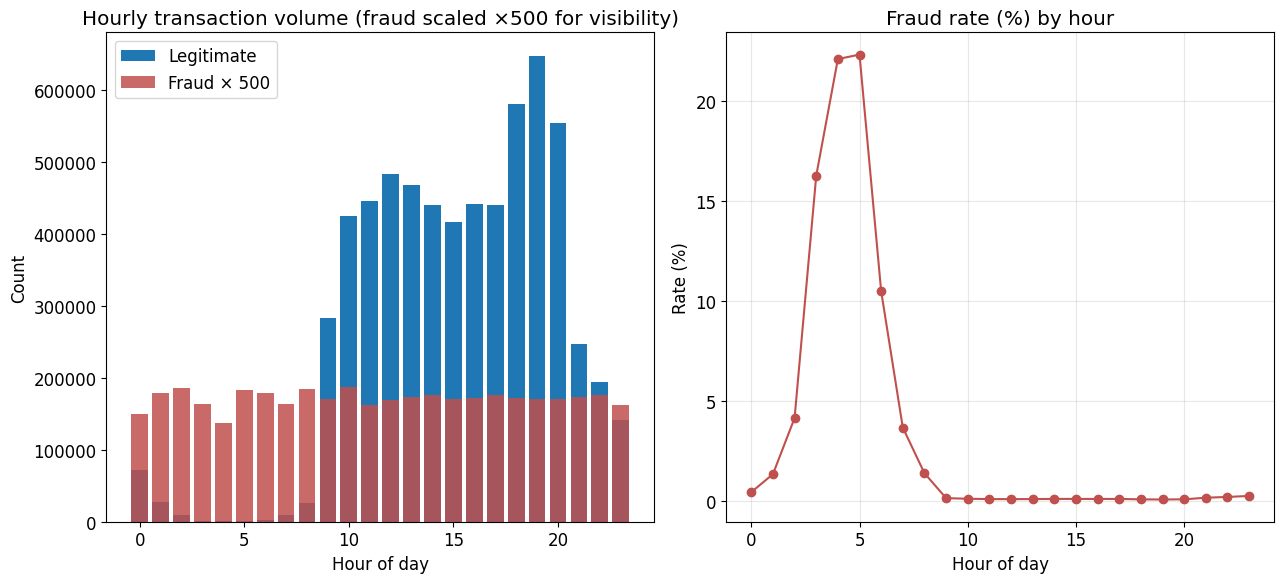

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
# int8 counts are cast to int64 before multiplying, to avoid overflow
axes[0].bar(hourly.index, hourly["legit_vol"].astype("int64"), color="#1f77b4", label="Legitimate")
axes[0].bar(hourly.index, hourly["fraud_vol"].astype("int64") * 500,
            color="#c0504d", label="Fraud × 500", alpha=0.85)
axes[0].set_title("Hourly transaction volume (fraud scaled ×500 for visibility)")
axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("Count"); axes[0].legend()

axes[1].plot(hourly.index, hourly["fraud_rate"] * 100, marker="o", color="#c0504d")
axes[1].set_title("Fraud rate (%) by hour")
axes[1].set_xlabel("Hour of day"); axes[1].set_ylabel("Rate (%)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Task 3.11:** Compare the overnight fraud rate with the overall rate.

In [19]:
night = df[df["hour"].isin(list(range(22, 24)) + list(range(0, 6)))]
print(f"Overall fraud rate:                  {df['isFraud'].mean():.4%}")
print(f"Non-business-hours fraud rate (22-06): {night['isFraud'].mean():.4%}")

Overall fraud rate:                  0.1291%
Non-business-hours fraud rate (22-06): 0.5954%


**Finding.** The fraud *count* is roughly flat across the 24 hours while
legitimate volume collapses overnight, so the fraud *rate* is several times
higher outside business hours. Fraudsters do not keep office hours; legitimate
users do.

### 3.5 Are merchant accounts relevant?

Account names start with `C` for customers and `M` for merchants.

**Task 3.12:** Do merchants ever send money, or receive anything other than
payments?

In [20]:
merchants_as_originators = df["nameOrig"].str.contains("M").any()
print(f"Merchants among originator accounts: {merchants_as_originators}")

non_payment_merchant_dest = (df.loc[df["nameDest"].str.contains("M"), "type"] != "PAYMENT").any()
print(f"Merchants as destinations for non-PAYMENT types: {non_payment_merchant_dest}")

Merchants among originator accounts: False


Merchants as destinations for non-PAYMENT types: False


**Finding:** merchants appear only as *destinations* of PAYMENT transactions,
which never contain fraud, so merchant labels carry nothing for fraud detection.

### 3.6 Do fraudulent accounts appear across transaction types?

The expected pattern is TRANSFER to a mule account, then CASH_OUT from it. If
so, destinations of fraudulent transfers should originate cash-outs.

**Task 3.13:** Test that link.

In [21]:
fraud_transfer_dest_in_cash_out_origs = fraud_transfers["nameDest"].isin(fraud_cashouts["nameOrig"]).any()
print(f"Fraud TRANSFER destinations that also originate fraud CASH_OUTS: {fraud_transfer_dest_in_cash_out_origs}")

genuine_cashouts = df[(df["isFraud"] == 0) & (df["type"] == "CASH_OUT")]
fraud_dests_in_genuine_cashouts = fraud_transfers.loc[
    fraud_transfers["nameDest"].isin(genuine_cashouts["nameOrig"].drop_duplicates())
]
print(f"\nFraud TRANSFER destinations that originate genuine CASH_OUTs: {len(fraud_dests_in_genuine_cashouts)}")

Fraud TRANSFER destinations that also originate fraud CASH_OUTS: False



Fraud TRANSFER destinations that originate genuine CASH_OUTs: 3


**Finding:** there is **no link** between fraudulent TRANSFER destinations and
CASH_OUT originators; the account names appear to be anonymised in a way that
breaks the chain. Since `nameOrig` and `nameDest` link nothing, and would create
millions of categories for any model, **both are dropped**.

---
## 4. Clean: keep the transactions that matter

From section 3:

1. **Keep only** TRANSFER and CASH_OUT (fraud occurs only there)
2. **Drop** `nameOrig` and `nameDest` (no information, sections 3.5 and 3.6)
3. **Drop** `isFlaggedFraud` (near-zero recall, section 3.3)
4. **Encode** the transaction type as 0 = TRANSFER, 1 = CASH_OUT

**Task 4.1:** Filter to TRANSFER and CASH_OUT.

In [22]:
fraud_relevant = df[(df["type"] == "TRANSFER") | (df["type"] == "CASH_OUT")].copy()

print(f"Original dataset: {len(df):>10,} transactions")
print(f"After filtering:  {len(fraud_relevant):>10,} transactions")
print(f"Rows removed:    {len(df) - len(fraud_relevant):>10,} "
      f"({(len(df) - len(fraud_relevant)) / len(df):.1%})")

Original dataset:  6,362,620 transactions
After filtering:   2,770,409 transactions
Rows removed:     3,592,211 (56.5%)


**Task 4.2:** Separate the target from the features, drop the three columns, and
encode the type. `.map()` replaces the column rather than writing integers into
a text column (which pandas 3 refuses), and it leaves a missing value for any
unexpected type, which the check catches.

In [23]:
RANDOM_STATE = CONFIG["random_seed"]

target = fraud_relevant["isFraud"]                                          # what we predict
features = fraud_relevant.drop("isFraud", axis=1)                           # what we predict it from
features = features.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)

TYPE_ENCODING = {"TRANSFER": 0, "CASH_OUT": 1}
features["type"] = features["type"].map(TYPE_ENCODING)
assert features["type"].notna().all(), "unexpected transaction type after filtering"
features["type"] = features["type"].astype("int8")

print(f"Final feature columns: {list(features.columns)}")
print(f"Target distribution: {target.value_counts().to_dict()}")
print(f"Fraud rate in filtered data: {target.mean():.4%}")

Final feature columns: ['step', 'type', 'amount', 'oldBalanceOrig', 'newBalanceOrig', 'oldBalanceDest', 'newBalanceDest', 'hour']
Target distribution: {0: 2762196, 1: 8213}
Fraud rate in filtered data: 0.2965%


In [24]:
# Check your work: filtering removed rows but not a single fraud
assert int(target.sum()) == 8_213
assert set(features["type"].unique()) <= {0, 1}

**Task 4.3:** Release the raw data. `df` (6.36 million rows) is never read again.
Every exploratory frame from section 3 is a slice of it and keeps its memory
alive, so they are released together; `features` and `target` are kept.

In [25]:
_before = len(df)
_released = []
for _name in [
    "df", "fraud_relevant", "transfers", "flagged", "not_flagged",
    "fraud_transfers", "fraud_cashouts", "genuine_cashouts",
    "zero_dest_not_flagged", "fraud_dests_in_genuine_cashouts",
    "missed_above_threshold", "hourly", "night",
]:
    if globals().pop(_name, None) is not None:
        _released.append(_name)
_collected = gc.collect()

print(f"Released {len(_released)} frames derived from the raw {_before:,} rows "
      f"({_collected:,} objects collected).")
print(f"Still held: features {features.shape}, target {target.shape}")

Released 13 frames derived from the raw 6,362,620 rows (66 objects collected).
Still held: features (2770409, 8), target (2770409,)


---
## 5. Hidden missing values

`isnull()` found nothing in section 3.1, but financial data often holds
**hidden missing values**: zeros that mean "not recorded" rather than zero.
When a non-zero amount moves but the destination balance is zero both before
and after, either the balance was not recorded or the account exists only for
this transaction, which is itself a fraud signal. Filling such zeros in blindly
could destroy that signal, so first measure it.

**Task 5.1:** Compare how often fraud and genuine transactions have a zero
destination balance before and after a non-zero transfer.

In [26]:
fraud_rows = features.loc[target == 1]
genuine_rows = features.loc[target == 0]


def zero_dest_share(rows):
    # Share of rows where a non-zero amount leaves the destination balance at zero before and after
    zero_pair = (rows["oldBalanceDest"] == 0) & (rows["newBalanceDest"] == 0) & (rows["amount"] != 0)
    return zero_pair.mean()


print(f"Fraud transactions with zero dest balance: {zero_dest_share(fraud_rows):.2%}")
print(f"Genuine transactions with zero dest balance: {zero_dest_share(genuine_rows):.2%}")

Fraud transactions with zero dest balance: 49.56%
Genuine transactions with zero dest balance: 0.06%


**Finding:** about half of frauds have this zero pattern against well under 1%
of genuine transactions. It is a strong fraud signal, so:

- **Destination zeros** become -1, a sentinel value that keeps the signal and
  cannot be confused with a real zero balance.
- **Origin zeros** become NaN, so the model treats them as missing.

**Task 5.2:** Apply both replacements.

In [27]:
dest_zero_pair = (features["oldBalanceDest"] == 0) & (features["newBalanceDest"] == 0) & (features["amount"] != 0)
features.loc[dest_zero_pair, ["oldBalanceDest", "newBalanceDest"]] = -1

orig_zero_pair = (features["oldBalanceOrig"] == 0) & (features["newBalanceOrig"] == 0) & (features["amount"] != 0)
features.loc[orig_zero_pair, ["oldBalanceOrig", "newBalanceOrig"]] = np.nan

print("Sentinel values imputed successfully.")
print(f"NaN values in features: {features.isnull().sum().sum():,}")

Sentinel values imputed successfully.
NaN values in features: 2,617,132


In [28]:
# Check your work: two NaNs (old and new origin balance) per origin zero-pair, nothing else
assert features.isnull().sum().sum() == 2 * orig_zero_pair.sum()

---
## 6. Feature engineering: balance discrepancies

Raw features describe what a transaction looks like. Engineered features can
capture what it *should* look like against what actually happened. For an
honest transaction the accounting identity holds:

> **sender's new balance = old balance - amount sent**
> **receiver's new balance = old balance + amount received**

Any deviation is a **balance discrepancy**, and discrepancies are a strong fraud
signal: the simulated fraud does not keep the ledger consistent.

**Task 6.1:** Compute the discrepancy on each side.

In [29]:
# Sender side: zero when the sender's balance fell by exactly the amount
features["errorBalanceOrig"] = features["newBalanceOrig"] + features["amount"] - features["oldBalanceOrig"]

# Recipient side: zero when the recipient's balance rose by exactly the amount
features["errorBalanceDest"] = features["oldBalanceDest"] + features["amount"] - features["newBalanceDest"]

print(f"Final feature set: {list(features.columns)}")
print(f"Shape: {features.shape}")

Final feature set: ['step', 'type', 'amount', 'oldBalanceOrig', 'newBalanceOrig', 'oldBalanceDest', 'newBalanceDest', 'hour', 'errorBalanceOrig', 'errorBalanceDest']
Shape: (2770409, 10)


---
## 7. Visualise: fingerprints of fraud against genuine

Before training any model, check whether the features actually separate the
classes. If they overlapped completely, no model would help.

**Task 7.1:** A helper for strip plots. Scattering all 2.77 million rows draws
nothing more than a sample does, because genuine points overplot each other, so
every fraud is drawn plus a fixed-seed sample of 200,000 genuine rows.

In [30]:
STRIP_GENUINE_SAMPLE = 200_000


def plot_strip(x_data, y_data, hue_data, figsize=(14, 9)):
    """Strip plot of genuine against fraudulent transactions (all fraud, sampled genuine)."""
    genuine_index = x_data.index[x_data == 0]
    fraud_index = x_data.index[x_data == 1]
    rng = np.random.RandomState(CONFIG["random_seed"])
    keep = genuine_index[rng.choice(len(genuine_index), size=min(STRIP_GENUINE_SAMPLE, len(genuine_index)),
                                    replace=False)].union(fraud_index)

    plt.figure(figsize=figsize)
    colours = plt.cm.tab10(np.linspace(0, 1, 9))
    with sns.axes_style("ticks"):
        ax = sns.stripplot(x=x_data.loc[keep], y=y_data.loc[keep], hue=hue_data.loc[keep],
                           jitter=0.4, marker=".", size=4, palette=colours, rasterized=True)
        ax.set_xlabel("")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["genuine (200,000 sampled)", "fraudulent (all)"], size=16)
        for spine in ["top", "bottom", "left", "right"]:
            ax.spines[spine].set_linewidth(2)
    return ax

**Task 7.2:** Do fraudulent transactions cluster in time?

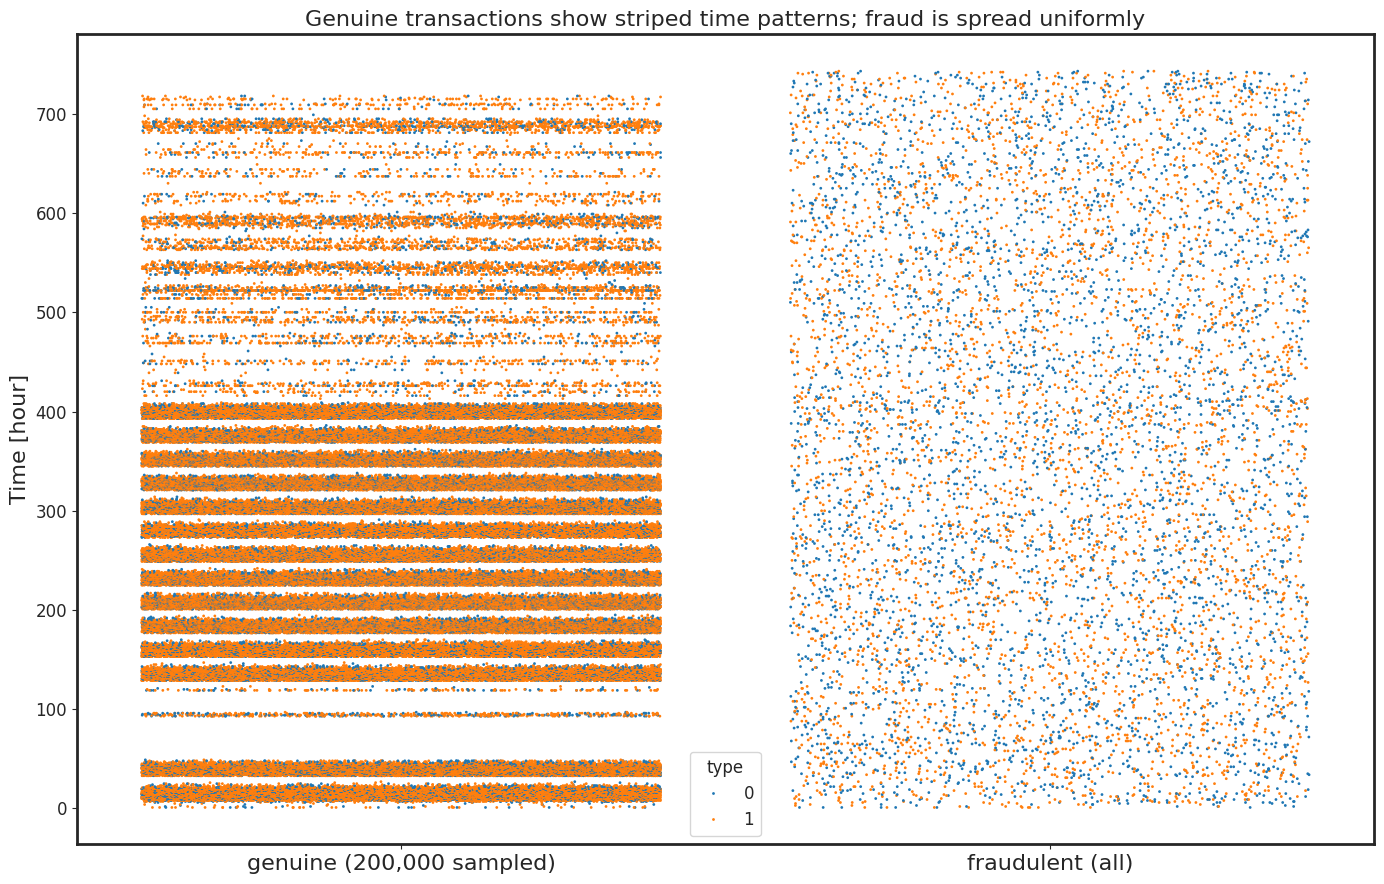

In [31]:
ax = plot_strip(target, features["step"], features["type"])
ax.set_ylabel("Time [hour]", size=16)
ax.set_title("Genuine transactions show striped time patterns; fraud is spread uniformly", size=16)
plt.tight_layout()
plt.show()

Genuine transactions show a striped, daily pattern; fraud is spread evenly over
all hours, consistent with section 3.4.

**Task 7.3:** Does the amount separate the classes?

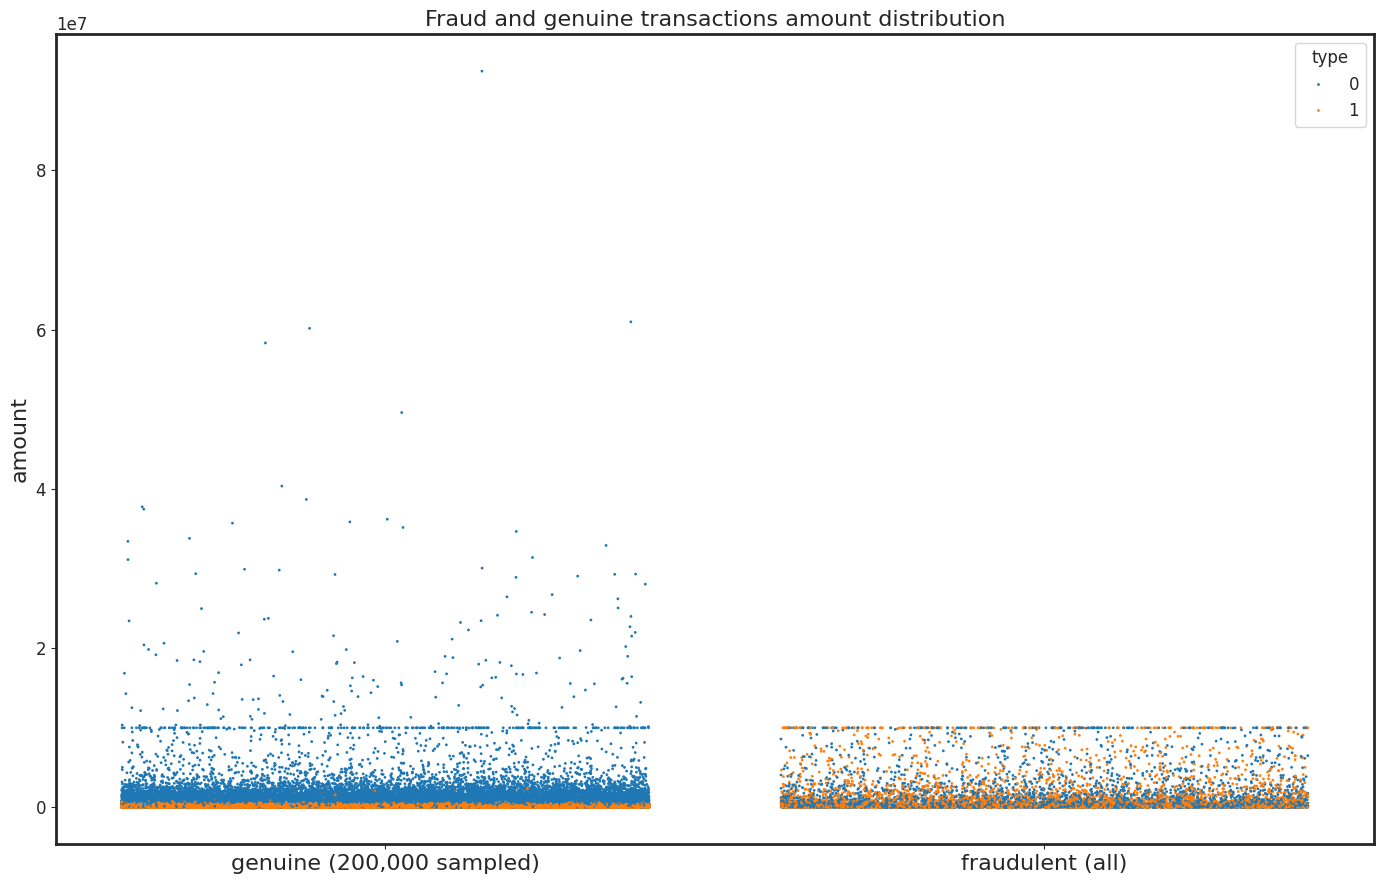

In [32]:
ax = plot_strip(target, features["amount"], features["type"], figsize=(14, 9))
ax.set_ylabel("amount", size=16)
ax.set_title("Fraud and genuine transactions amount distribution", size=16)
plt.tight_layout()
plt.show()

Not clearly: both classes span similar amounts, which is why raw features alone
are not enough.

**Task 7.4:** Does the destination discrepancy separate them?

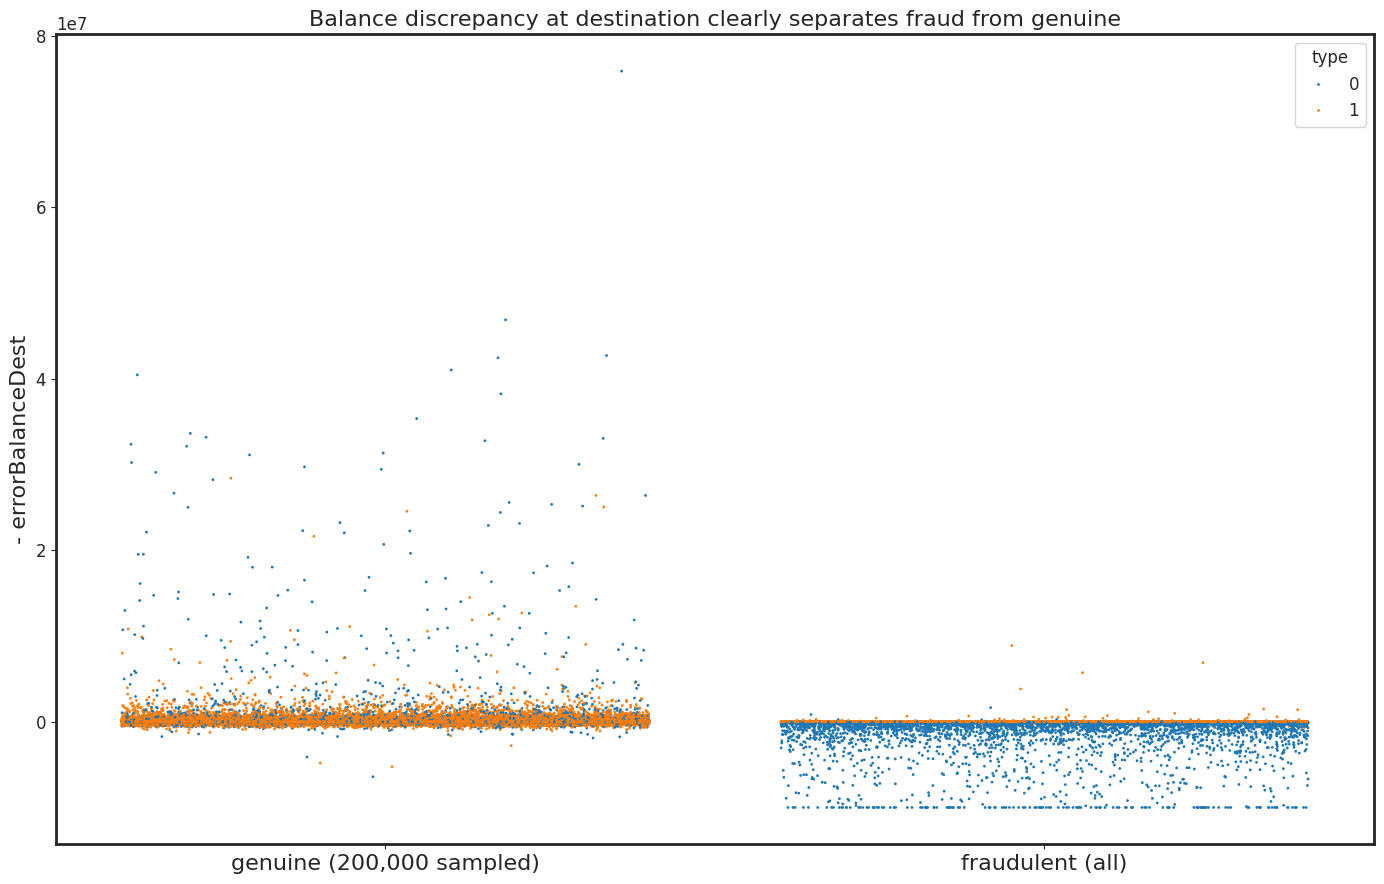

In [33]:
ax = plot_strip(target, -features["errorBalanceDest"], features["type"], figsize=(14, 9))
ax.set_ylabel("- errorBalanceDest", size=16)
ax.set_title("Balance discrepancy at destination clearly separates fraud from genuine", size=16)
plt.tight_layout()
plt.show()

Yes: fraud and genuine transactions sit on opposite sides of zero, a mirror
image. This is the fingerprint the engineered feature was built to expose.

**Task 7.5:** Compare the correlation structure of the features within each
class (excluding `step`, which is a time index).

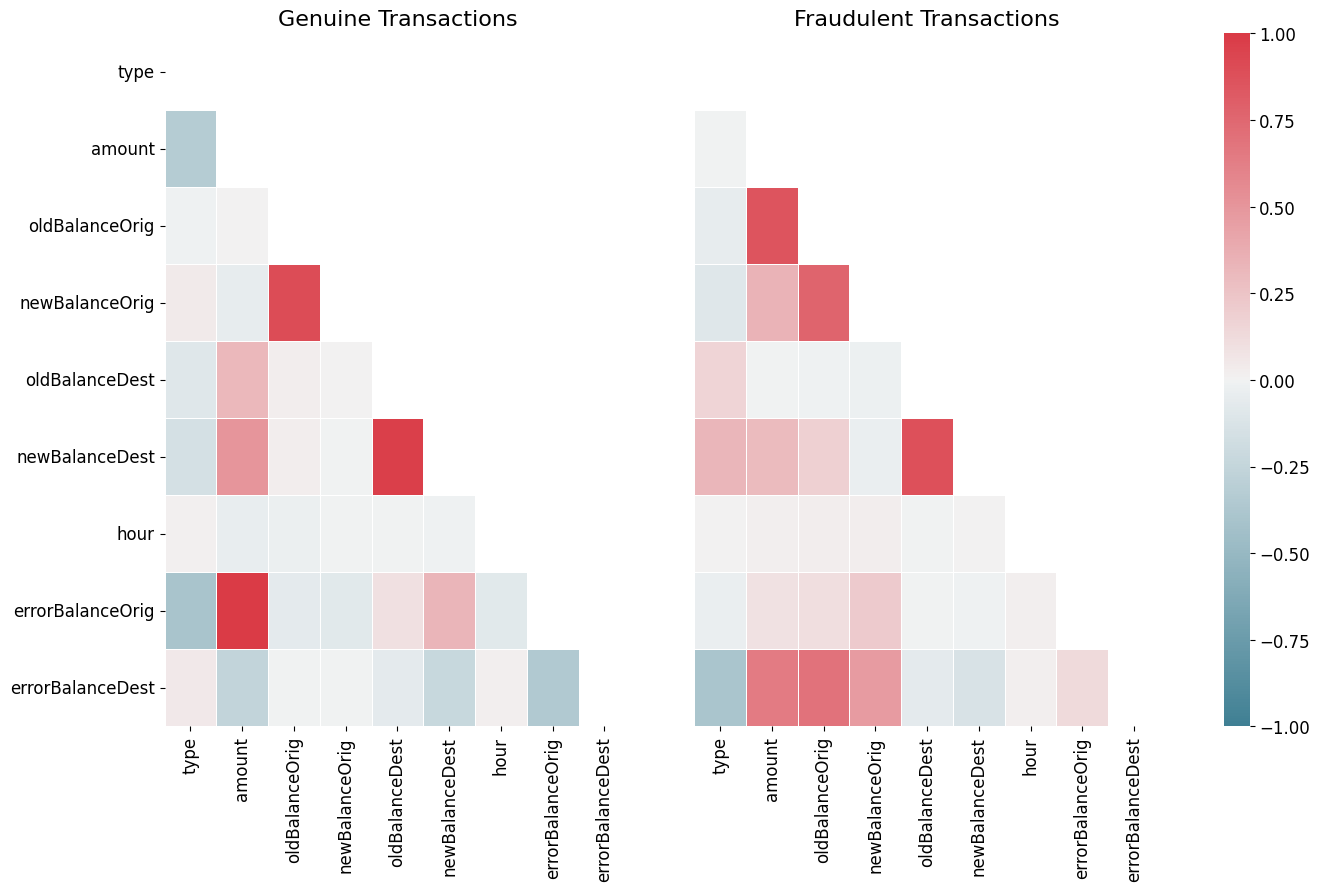

In [34]:
fraud_rows = features.loc[target == 1]
genuine_rows = features.loc[target == 0]
corr_genuine = genuine_rows.loc[:, features.columns != "step"].corr()
corr_fraud = fraud_rows.loc[:, features.columns != "step"].corr()

mask = np.zeros_like(corr_genuine)
mask[np.triu_indices_from(corr_genuine)] = True   # show each pair once
fig, (ax1, ax2, cbar_ax) = plt.subplots(
    1, 3, gridspec_kw={"width_ratios": (.9, .9, .05), "wspace": 0.2}, figsize=(14, 9))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_genuine, mask=mask, cmap=cmap, vmin=-1, vmax=1, linewidth=0.5, cbar=False, ax=ax1)
ax1.set_title("Genuine Transactions", size=16)
sns.heatmap(corr_fraud, mask=mask, cmap=cmap, vmin=-1, vmax=1, linewidth=0.5, yticklabels=False,
            cbar=True, cbar_ax=cbar_ax, ax=ax2)
ax2.set_title("Fraudulent Transactions", size=16)
plt.tight_layout()
plt.show()

The correlation structures differ sharply between the classes, which confirms
there is signal for a model to learn.

---
## 8. Split by time

The split is **time-based**, not random. In production a model always scores
*future* transactions from *past* data; a random split would leak the future
into training and inflate the metrics. Training covers steps 1 to 490 and the
test set steps 491 to 743.

**`step` itself is excluded from the model's features.** It is the split
variable, so every test value of `step` is larger than any value seen in
training. Trees cannot extrapolate beyond their training range; they would send
every test row down whichever branch held the largest training step, an
arbitrary decision dressed up as a learned one. In production every new
transaction would drift further outside the fitted range. `hour` (`step % 24`)
is kept instead: hour of day recurs, the test window covers the same 24 values,
and section 3.4 showed the fraud rate varies across them. The shipped pipeline
excludes `step` for the same reason.

**Task 8.1:** Split the data.

In [35]:
SPLIT_STEP = CONFIG["split_step"]
MODEL_COLS = [c for c in features.columns if c != "step"]   # every feature except the split variable

train_mask = features["step"] <= SPLIT_STEP
test_mask = features["step"] > SPLIT_STEP

X_train = features.loc[train_mask, MODEL_COLS]
y_train = target[train_mask]
X_test = features.loc[test_mask, MODEL_COLS]
y_test = target[test_mask]

print(f"Time-based split at step {SPLIT_STEP} (no shuffling)")
print(f"  Train  steps 1-{SPLIT_STEP}:   {len(X_train):>10,} rows | fraud rate {y_train.mean():.4%}")
print(f"  Test   steps {SPLIT_STEP + 1}-743: {len(X_test):>10,} rows | fraud rate {y_test.mean():.4%}")
print(f"\nModel features ({len(MODEL_COLS)}):", MODEL_COLS)
print(f"Fraud rate ratio, test vs train: {y_test.mean() / y_train.mean():.1f}x")

Time-based split at step 490 (no shuffling)
  Train  steps 1-490:    2,638,273 rows | fraud rate 0.2069%
  Test   steps 491-743:    132,136 rows | fraud rate 2.0842%

Model features (9): ['type', 'amount', 'oldBalanceOrig', 'newBalanceOrig', 'oldBalanceDest', 'newBalanceDest', 'hour', 'errorBalanceOrig', 'errorBalanceDest']
Fraud rate ratio, test vs train: 10.1x


In [36]:
# Check your work: every training row precedes every test row, and step is not a feature
assert features.loc[train_mask, "step"].max() < features.loc[test_mask, "step"].min()
assert "step" not in MODEL_COLS and len(X_train) + len(X_test) == len(features)

The test window has a much higher fraud rate than the training window. That is
a property of the data, not a mistake: PaySim's fraud is spread evenly over time
while legitimate volume falls away in the later steps, so a similar fraud count
lands in a smaller denominator.

---
# Part 2: Build and evaluate the models

## 9. The metric and the baseline

### Why PR-AUC instead of accuracy or ROC-AUC?

| Metric | Problem with imbalanced data |
|--------|------------------------------|
| **Accuracy** | Predicting "not fraud" every time scores 99.87% and catches nothing |
| **ROC-AUC** | Inflated by the enormous number of true negatives |
| **PR-AUC** | Focuses on the precision-recall trade-off within the fraud class |

> **What's PR-AUC?** Rank the transactions from most to least suspicious.
> Precision is the share of flagged transactions that really are fraud; recall
> is the share of all fraud that has been flagged. PR-AUC (average precision)
> summarises the trade-off in one number. A model that ranks at random scores
> the fraud rate, about 2% on the test window.

**Task 9.1:** Write one evaluation function, so every model is scored the same
way. It records PR-AUC, ROC-AUC, the best recall achievable while precision
stays at or above 99%, and F1 at the default 0.5 threshold.

In [37]:
results = {}


def evaluate(name, y_true, y_score, precision_floor=0.99):
    ap = average_precision_score(y_true, y_score)
    try:
        auc = roc_auc_score(y_true, y_score)
    except ValueError:
        auc = float("NaN")
    prec, rec, thr = precision_recall_curve(y_true, y_score)
    eligible = prec[:-1] >= precision_floor                       # thresholds that keep precision >= 99%
    r_at_floor = rec[:-1][eligible].max() if eligible.any() else 0.0
    f1_05 = f1_score(y_true, (y_score >= 0.5).astype(int))
    results[name] = {
        "PR-AUC": ap, "ROC-AUC": auc,
        f"Recall@{int(precision_floor * 100)}P": r_at_floor, "F1@0.5": f1_05,
    }
    print(f"{name:30s} PR-AUC={ap:.4f} ROC-AUC={auc:.4f} "
          f"R@99P={r_at_floor:.4f} F1@0.5={f1_05:.4f}")

**Task 9.2:** Score the baseline before any model. PaySim documents
`isFlaggedFraud` as a rule that flags TRANSFERs above 200,000. Section 3.3
showed the data does not follow that rule, so the baseline applies the
documented rule itself: it is a 200,000 TRANSFER rule, not the `isFlaggedFraud`
column. (`src/business_impact.py` scores the actual column instead.)

In [38]:
# Flag a TRANSFER (type 0) above 200,000; everything else is scored 0
baseline_score = ((X_test["type"] == 0) & (X_test["amount"] > 200_000)).astype(int)
evaluate("Baseline (200,000 TRANSFER rule)", y_test, baseline_score)

Baseline (200,000 TRANSFER rule) PR-AUC=0.0283 ROC-AUC=0.5888 R@99P=0.0000 F1@0.5=0.0761


Every model below is measured against this line.

---
## 10. Iterate: five models

### 10.1 XGBoost with class weights

XGBoost handles mixed features natively, and its `scale_pos_weight` parameter
addresses the imbalance directly: it tells the model that missing a fraud costs
more than raising a false alarm. Section 13.1 tests this against SMOTE
resampling.

**Task 10.1:** Compute the class weight, `count(genuine) / count(fraud)`, from
the training labels only. A hyperparameter computed with test labels would leak
the test window into the model.

In [39]:
class_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class weight (scale_pos_weight): {class_weight:.1f}")
print(f"Each fraud row in training is weighted as {class_weight:.0f} genuine rows")

Class weight (scale_pos_weight): 482.3
Each fraud row in training is weighted as 482 genuine rows


**Task 10.2:** Train a shallow XGBoost (trees of depth 3, every other setting at
the library default) and score the test window.

In [40]:
model = XGBClassifier(max_depth=3, scale_pos_weight=class_weight, n_jobs=N_JOBS)

# Fit on the training window; keep probabilities, not just 0/1 predictions
predicted_probabilities = model.fit(X_train, y_train).predict_proba(X_test)

pr_auc = average_precision_score(y_test, predicted_probabilities[:, 1])
print(f"PR-AUC Score: {pr_auc:.4f}")
evaluate("XGBoost (trained above)", y_test, predicted_probabilities[:, 1])

PR-AUC Score: 0.9989
XGBoost (trained above)        PR-AUC=0.9989 ROC-AUC=0.9990 R@99P=0.9989 F1@0.5=0.9960


### 10.2 Logistic regression

**Task 10.3:** Logistic regression cannot take missing values, and section 5 set
zero-pair origin balances to NaN. They are filled with the constant 1, which
cannot be confused with a genuine zero balance or with the -1 destination
sentinel; then the features are scaled.

In [41]:
lr_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value=1)),
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced",
                              solver="lbfgs", n_jobs=1, random_state=42)),
])
lr_pipe.fit(X_train, y_train)
evaluate("Logistic Regression", y_test, lr_pipe.predict_proba(X_test)[:, 1])

Logistic Regression            PR-AUC=0.7901 ROC-AUC=0.9795 R@99P=0.4503 F1@0.5=0.3842


### 10.3 Random forest

**Task 10.4:** A random forest with `balanced_subsample` weighting, which
rebalances the classes within each tree's sample. scikit-learn 1.4 and later fit
random forests on NaN directly.

In [42]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=16, min_samples_leaf=20,
    class_weight="balanced_subsample",
    n_jobs=RF_JOBS, random_state=42,
)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
evaluate("Random Forest", y_test, rf_probs)

Random Forest                  PR-AUC=1.0000 ROC-AUC=1.0000 R@99P=1.0000 F1@0.5=0.9998


### 10.4 LightGBM

**Task 10.5:** LightGBM, weighted by the same training-window class ratio.

In [43]:
import lightgbm as lgbm

lgb_model = LGBMClassifier(
    n_estimators=400, num_leaves=31, learning_rate=0.05, min_child_samples=5,
    scale_pos_weight=class_weight, n_jobs=N_JOBS, random_state=42, verbose=-1,
)
lgb_model.fit(X_train, y_train, callbacks=[lgbm.log_evaluation(period=0)])  # no per-iteration log lines
evaluate("LightGBM", y_test, lgb_model.predict_proba(X_test)[:, 1])

LightGBM                       PR-AUC=0.0338 ROC-AUC=0.6956 R@99P=0.0000 F1@0.5=0.0654


### 10.5 Stacking ensemble

**Task 10.6:** Combine a random forest, XGBoost and LightGBM, with a logistic
regression learning how to weigh their predictions (fitted on three-fold
out-of-sample predictions). Missing values are filled with -1 first so that
every model in the stack can use the same data. `n_jobs=1` on the stack itself
stops the nested parallelism described in Task 1.4.

In [44]:
X_train_imp = X_train.fillna(-1)
X_test_imp = X_test.fillna(-1)

stack = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(
            n_estimators=150, max_depth=16, min_samples_leaf=20,
            class_weight="balanced_subsample", n_jobs=RF_JOBS, random_state=42)),
        ("xgb", XGBClassifier(
            n_estimators=150, max_depth=6, learning_rate=0.1, scale_pos_weight=class_weight,
            eval_metric="aucpr", tree_method="hist", n_jobs=N_JOBS, random_state=42)),
        ("lgb", LGBMClassifier(
            n_estimators=300, num_leaves=31, learning_rate=0.05, min_child_samples=5,
            scale_pos_weight=class_weight, n_jobs=N_JOBS, random_state=42, verbose=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, class_weight="balanced"),
    cv=3,
    n_jobs=1,
    passthrough=False,
)
stack.fit(X_train_imp, y_train)
evaluate("Stacking Ensemble", y_test, stack.predict_proba(X_test_imp)[:, 1])

Stacking Ensemble              PR-AUC=1.0000 ROC-AUC=1.0000 R@99P=1.0000 F1@0.5=0.9996


---
## 11. Evaluate

### 11.1 Scoreboard and PR curves

**Task 11.1:** Put every model on one scoreboard, with the uplift over the
baseline rule.

In [45]:
results_df = pd.DataFrame(results).T.sort_values("PR-AUC", ascending=False)
baseline_ap = results["Baseline (200,000 TRANSFER rule)"]["PR-AUC"]
results_df["Uplift vs Baseline"] = results_df["PR-AUC"] / max(baseline_ap, 1e-9)

print("FINAL SCOREBOARD (held-out future window)")
print("=" * 90)
print(results_df.to_string(float_format=lambda x: f"{x:.4f}"))

FINAL SCOREBOARD (held-out future window)
                                  PR-AUC  ROC-AUC  Recall@99P  F1@0.5  Uplift vs Baseline
Random Forest                     1.0000   1.0000      1.0000  0.9998             35.3304
Stacking Ensemble                 1.0000   1.0000      1.0000  0.9996             35.3304
XGBoost (trained above)           0.9989   0.9990      0.9989  0.9960             35.2914
Logistic Regression               0.7901   0.9795      0.4503  0.3842             27.9133
LightGBM                          0.0338   0.6956      0.0000  0.0654              1.1942
Baseline (200,000 TRANSFER rule)  0.0283   0.5888      0.0000  0.0761              1.0000


**Task 11.2:** Draw the precision-recall curve of every model.

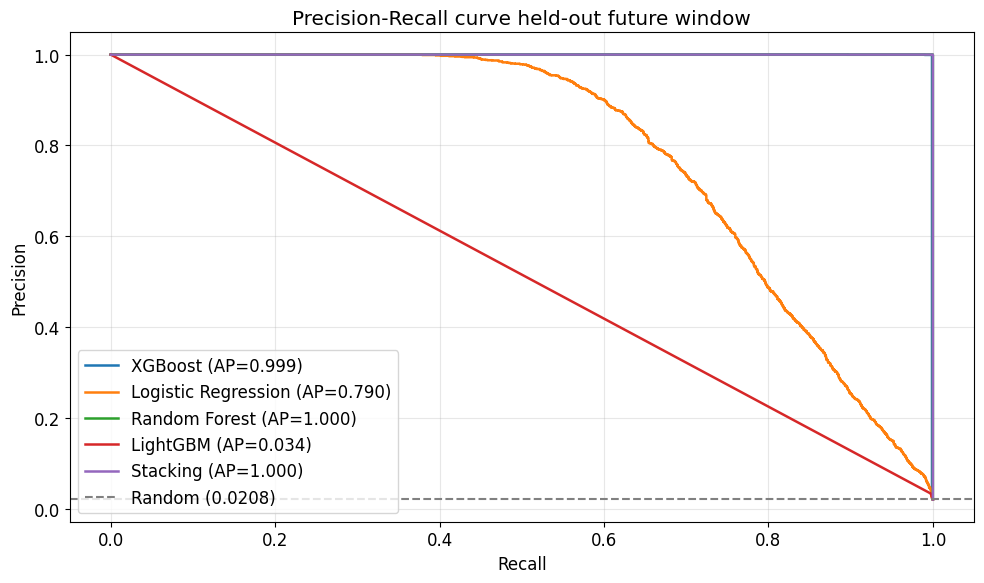

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))
model_scores = [
    ("XGBoost", predicted_probabilities[:, 1]),
    ("Logistic Regression", lr_pipe.predict_proba(X_test)[:, 1]),
    ("Random Forest", rf_probs),
    ("LightGBM", lgb_model.predict_proba(X_test)[:, 1]),
    ("Stacking", stack.predict_proba(X_test_imp)[:, 1]),
]
for name, score in model_scores:
    p, r, _ = precision_recall_curve(y_test, score)
    ax.plot(r, p, label=f"{name} (AP={average_precision_score(y_test, score):.3f})", linewidth=1.8)

ax.axhline(y_test.mean(), color="gray", linestyle="--", label=f"Random ({y_test.mean():.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve held-out future window")
ax.legend(loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the scoreboard.**

A PR-AUC of exactly 1.0000 for the random forest and the stacking ensemble on 2,754 test frauds is not evidence
of a better model. Once the balance discrepancy features exist, PaySim's fraud labels are close to a
deterministic function of them, so several models separate the classes almost perfectly; the class-weighted
XGBoost (0.9989) sits in the same place.

LightGBM is the exception, at PR-AUC 0.0338, barely above the 0.0283 of the baseline rule. With 400 trees of
31 leaves, `min_child_samples=5` and the same class weight of 482, it collapsed on the later window. This run
does not isolate which setting causes that, and the shipped pipeline does not use LightGBM.

### 11.2 Operating point at 99% precision

When the model flags a transaction, fraud operations freezes the customer's
funds. False alarms are therefore expensive, in customer trust and regulatory
complaints rather than money lost. The sensible operating point is the
**highest recall achievable while precision stays at or above 99%**.

**Task 11.3:** Find that threshold on the XGBoost scores and print the confusion
matrix there.

In [47]:
PRECISION_FLOOR = 0.99
prec, rec, thr = precision_recall_curve(y_test, predicted_probabilities[:, 1])
eligible = prec[:-1] >= PRECISION_FLOOR

if eligible.any():
    best = int(eligible.nonzero()[0][rec[:-1][eligible].argmax()])   # highest recall among eligible thresholds
    operating_threshold = float(thr[best])
    print(f"Operating threshold (XGBoost):  {operating_threshold:.4f}")
    print(f"Precision at threshold:         {prec[best]:.4f}")
    print(f"Recall at threshold:            {rec[best]:.4f}  (target >= 0.85)")

    y_pred_op = (predicted_probabilities[:, 1] >= operating_threshold).astype(int)
    cm_op = confusion_matrix(y_test, y_pred_op)
    print("\nConfusion matrix at operating point:")
    print(pd.DataFrame(cm_op, index=["actual_legit", "actual_fraud"], columns=["pred_legit", "pred_fraud"]))
    print("\n" + classification_report(y_test, y_pred_op, target_names=["legit", "fraud"]))
else:
    operating_threshold = None
    print(f"No threshold achieves precision >= {PRECISION_FLOOR:.0%}. Review calibration.")

Operating threshold (XGBoost):  0.3602
Precision at threshold:         0.9903
Recall at threshold:            0.9989  (target >= 0.85)

Confusion matrix at operating point:
              pred_legit  pred_fraud
actual_legit      129355          27
actual_fraud           3        2751

              precision    recall  f1-score   support

       legit       1.00      1.00      1.00    129382
       fraud       0.99      1.00      0.99      2754

    accuracy                           1.00    132136
   macro avg       1.00      1.00      1.00    132136
weighted avg       1.00      1.00      1.00    132136



### 11.3 Calibration: does the model mean what it says?

A model can rank fraud correctly (high PR-AUC) while returning poorly calibrated
probabilities. Where fraud operations uses several thresholds (auto-approve,
review, block), miscalibration distorts every one of them. A reliability
diagram plots predicted probability against observed frequency; a calibrated
model sits on the diagonal. The **Brier score** (mean squared error of the
probabilities, lower is better) summarises the gap.

**Task 11.4:** Draw the reliability diagram and compute the Brier score.

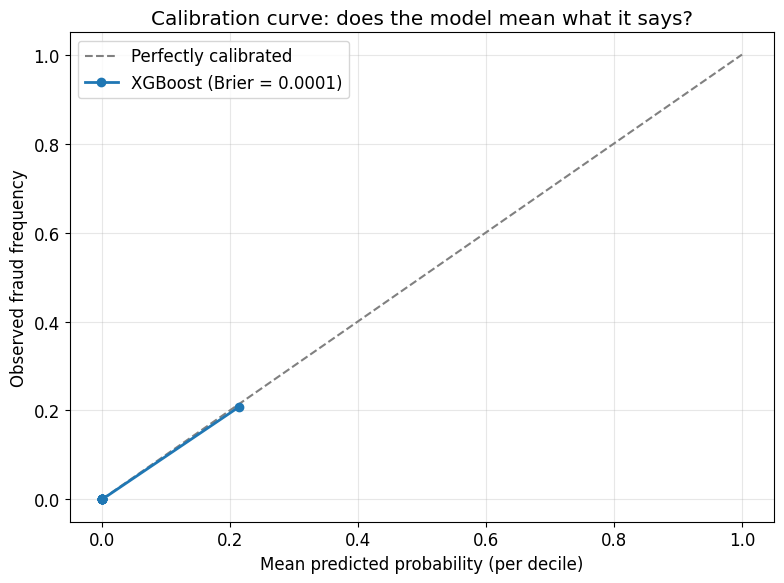

Brier score: 0.0001
Lower is better. For context, a model that always predicts the base rate
would score approximately 0.0204.


In [48]:
xgb_scores = predicted_probabilities[:, 1]
brier = brier_score_loss(y_test, xgb_scores)

# Ten bins with similar numbers of transactions each
prob_true, prob_pred = calibration_curve(y_test, xgb_scores, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.plot(prob_pred, prob_true, marker="o", linewidth=2, label=f"XGBoost (Brier = {brier:.4f})")
ax.set_xlabel("Mean predicted probability (per decile)")
ax.set_ylabel("Observed fraud frequency")
ax.set_title("Calibration curve: does the model mean what it says?")
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Brier score: {brier:.4f}")
print("Lower is better. For context, a model that always predicts the base rate")
print(f"would score approximately {y_test.mean() * (1 - y_test.mean()):.4f}.")

### 11.4 Permutation importance against tree importance

Tree importance (`feature_importances_`) measures how much each feature's splits
reduce the loss. When two features carry the same signal, it tends to split the
credit between them. **Permutation importance** is cleaner: shuffle one feature
on the test set and measure how far PR-AUC drops. That drop is the feature's
irreplaceable contribution. A feature high on tree importance but low on
permutation importance is substitutable: another feature carries the same
signal.

**Task 11.5:** Compute both on 10,000 test rows (permuting every feature five
times over the full test set is slow).

In [49]:
SAMPLE_N = min(10_000, len(X_test))
sample_idx = np.random.RandomState(42).choice(len(X_test), size=SAMPLE_N, replace=False)
X_samp = X_test.iloc[sample_idx]
y_samp = y_test.iloc[sample_idx]

perm = permutation_importance(model, X_samp, y_samp, scoring="average_precision",
                              n_repeats=5, n_jobs=N_JOBS, random_state=42)

importance_cmp = pd.DataFrame({
    "Tree importance":        model.feature_importances_,
    "Permutation importance": perm.importances_mean,
    "Permutation std":        perm.importances_std,
}, index=X_train.columns).sort_values("Permutation importance", ascending=False)

print(f"Feature importance comparison on {SAMPLE_N:,} of {len(X_test):,} test rows (sorted by permutation):")
print(importance_cmp.round(4))

Feature importance comparison on 10,000 of 132,136 test rows (sorted by permutation):
                  Tree importance  Permutation importance  Permutation std
errorBalanceOrig           0.5379                  0.8999           0.0082
newBalanceOrig             0.1719                  0.7774           0.0112
oldBalanceOrig             0.0310                  0.3899           0.0199
amount                     0.0260                  0.0543           0.0053
newBalanceDest             0.0148                  0.0508           0.0163
errorBalanceDest           0.0890                  0.0131           0.0074
oldBalanceDest             0.0144                  0.0054           0.0042
type                       0.0006                  0.0000           0.0000
hour                       0.1145                  0.0000           0.0000


**Task 11.6:** Plot the two rankings side by side.

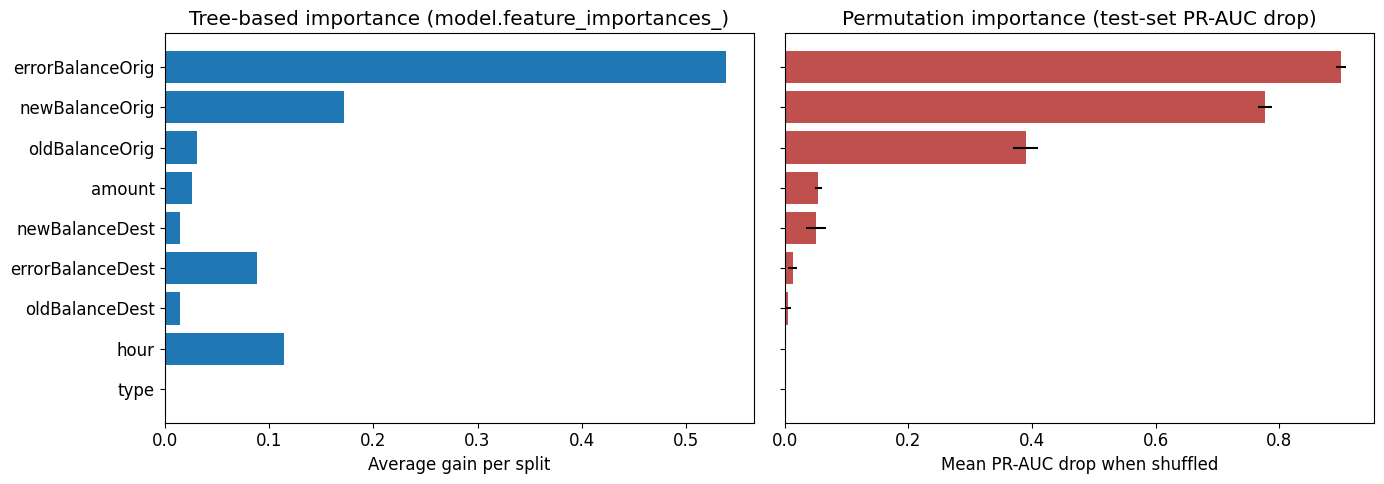

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
imp = importance_cmp.sort_values("Permutation importance")
ax1.barh(imp.index, imp["Tree importance"], color="#1f77b4")
ax1.set_title("Tree-based importance (model.feature_importances_)")
ax1.set_xlabel("Average gain per split")
ax2.barh(imp.index, imp["Permutation importance"], xerr=imp["Permutation std"], color="#c0504d")
ax2.set_title("Permutation importance (test-set PR-AUC drop)")
ax2.set_xlabel("Mean PR-AUC drop when shuffled")
plt.tight_layout()
plt.show()

---
## 12. The cost trade-off

The 99%-precision operating point is a reasonable default, but no deployment
should ship it without the client's actual cost ratio. A missed fraud costs
money directly; a false alarm costs customer goodwill, regulatory overhead and
review time. If a missed fraud costs 10 times a false alarm
(`CONFIG["fn_fp_cost_ratio"]`), the cheapest threshold may differ from the
99%-precision one.

**Task 12.1:** Sweep the threshold from 0.01 to 0.99, count missed frauds (FN)
and false alarms (FP) at each, and compute the cost 10 x FN + FP.

In [51]:
FN_FP_COST_RATIO = CONFIG["fn_fp_cost_ratio"]
thresholds = np.linspace(0.01, 0.99, 99)

fns, fps, costs = [], [], []
for t in thresholds:
    pred = (predicted_probabilities[:, 1] >= t).astype(int)
    fn = int(((pred == 0) & (y_test == 1)).sum())    # frauds let through
    fp = int(((pred == 1) & (y_test == 0)).sum())    # genuine transactions frozen
    fns.append(fn); fps.append(fp)
    costs.append(FN_FP_COST_RATIO * fn + fp)

costs = np.array(costs)
optimal_idx = int(costs.argmin())
optimal_threshold = float(thresholds[optimal_idx])
print(f"Cost-optimal threshold:      {optimal_threshold:.4f}")
print(f"Expected cost at that point: {costs[optimal_idx]:,.0f} units")
print(f"FN count at that point:      {fns[optimal_idx]}")
print(f"FP count at that point:      {fps[optimal_idx]}")

Cost-optimal threshold:      0.9600
Expected cost at that point: 32 units
FN count at that point:      3
FP count at that point:      2


**Task 12.2:** Plot the trade-off and the cost curve.

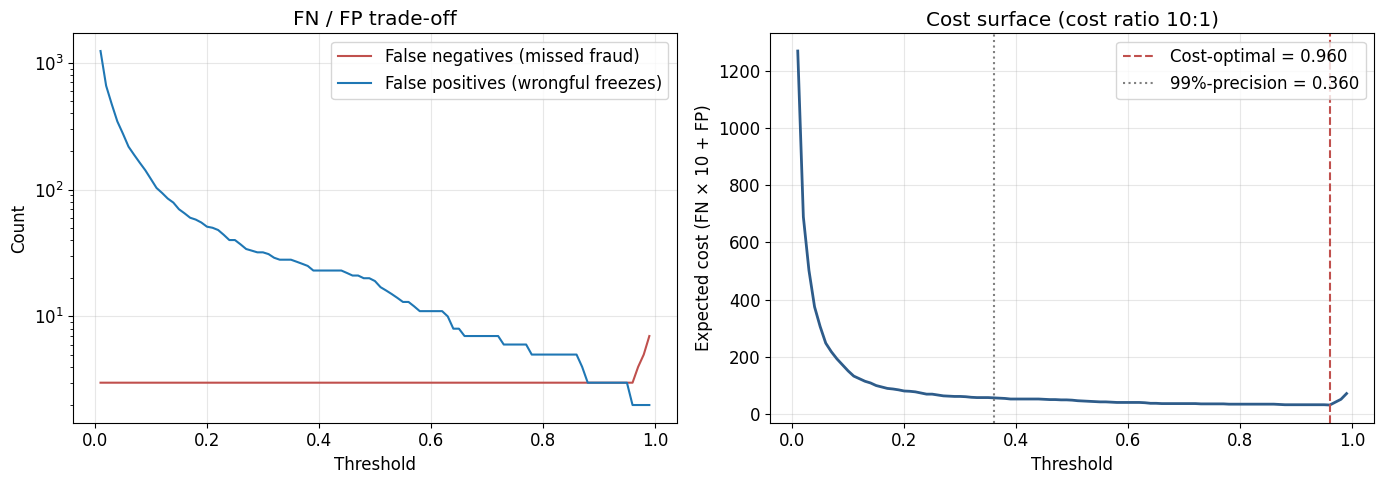

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(thresholds, fns, label="False negatives (missed fraud)", color="#c0504d")
ax1.plot(thresholds, fps, label="False positives (wrongful freezes)", color="#1f77b4")
ax1.set_xlabel("Threshold"); ax1.set_ylabel("Count")
ax1.set_title("FN / FP trade-off")
ax1.set_yscale("log"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(thresholds, costs, color="#2e5c8a", linewidth=2)
ax2.axvline(optimal_threshold, color="#c0504d", linestyle="--", label=f"Cost-optimal = {optimal_threshold:.3f}")
if operating_threshold is not None:
    ax2.axvline(operating_threshold, color="gray", linestyle=":", label=f"99%-precision = {operating_threshold:.3f}")
ax2.set_xlabel("Threshold")
ax2.set_ylabel(f"Expected cost (FN × {FN_FP_COST_RATIO} + FP)")
ax2.set_title(f"Cost surface (cost ratio {FN_FP_COST_RATIO}:1)")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 13. Ablation and explanations

### 13.1 SMOTE: testing the textbook advice

Textbook advice for imbalanced classification is "resample the minority class
with SMOTE". SMOTE creates synthetic fraud rows by interpolating between real
frauds, regardless of when they occurred. **Hypothesis:** if fraud behaviour
changed over PaySim's 31 days, those synthetic rows would mix patterns from
different periods, and a model trained on them would do worse on the later test
window than the class-weighted XGBoost of section 10.1.

**The test:** retrain the same XGBoost on SMOTE-resampled data, with every
setting identical except `scale_pos_weight`, set to 1 because SMOTE has already
balanced the classes. SMOTE cannot compute neighbours with NaN, so missing
values are filled with -1 first; the comparison therefore changes two things at
once, the missing-value handling and the rebalancing method.

**Task 13.1:** Resample the training window with SMOTE.

In [53]:
X_train_filled = X_train.fillna(-1)
X_test_filled = X_test.fillna(-1)

print("Resampling with SMOTE...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_filled, y_train)
print(f"  Original training: {len(X_train_filled):>10,} rows | fraud = {int(y_train.sum()):>6,}")
print(f"  SMOTE resampled:   {len(X_train_sm):>10,} rows | fraud = {int(y_train_sm.sum()):>6,}")

Resampling with SMOTE...


  Original training:  2,638,273 rows | fraud =  5,459
  SMOTE resampled:    5,265,628 rows | fraud = 2,632,814


**Task 13.2:** Retrain XGBoost on the resampled data and compare.

In [54]:
xgb_smote = XGBClassifier(max_depth=3, scale_pos_weight=1, n_jobs=N_JOBS)   # classes already balanced
xgb_smote.fit(X_train_sm, y_train_sm)
smote_probs = xgb_smote.predict_proba(X_test_filled)[:, 1]
evaluate("XGBoost + SMOTE (ablation)", y_test, smote_probs)

original_ap = results["XGBoost (trained above)"]["PR-AUC"]
smote_ap = results["XGBoost + SMOTE (ablation)"]["PR-AUC"]
delta = original_ap - smote_ap
direction = "underperformed" if delta > 0 else "outperformed"
print(f"\nABLATION RESULT")
print(f"  XGBoost + scale_pos_weight:  PR-AUC = {original_ap:.4f}")
print(f"  XGBoost + SMOTE:              PR-AUC = {smote_ap:.4f}")
print(f"  Delta (original - SMOTE):    {delta:+.4f}  (SMOTE {direction} by {abs(delta) * 100:.2f} pp)")

XGBoost + SMOTE (ablation)     PR-AUC=0.9995 ROC-AUC=1.0000 R@99P=0.9949 F1@0.5=0.9939

ABLATION RESULT
  XGBoost + scale_pos_weight:  PR-AUC = 0.9989
  XGBoost + SMOTE:              PR-AUC = 0.9995
  Delta (original - SMOTE):    -0.0006  (SMOTE outperformed by 0.06 pp)


**Interpreting the delta.**

SMOTE reached PR-AUC 0.9995 against 0.9989 for the class-weighted model, a difference of 0.06 points. The
hypothesis is rejected: interpolating fraud rows across the training window did not hurt performance on the
later test window. At this level the two approaches are indistinguishable on PaySim, and the comparison also
changes the missing-value handling (see above), so it does not favour either method in general.

The shipped pipeline treats the class weight as a hyperparameter instead: `src/tune.py`, choosing only on data
before every reporting window, picked `scale_pos_weight` 2.14.

### 13.2 SHAP: why the model flags a transaction

> **What's SHAP?** For one transaction, SHAP splits the model's score into a
> contribution from each feature, measured against an average transaction. A
> positive value pushes towards fraud, a negative one towards genuine.

**Task 13.3:** Draw a SHAP beeswarm for the XGBoost model on 2,000 test rows.
Each dot is one transaction; its colour is the feature's value and its position
the push it gives.

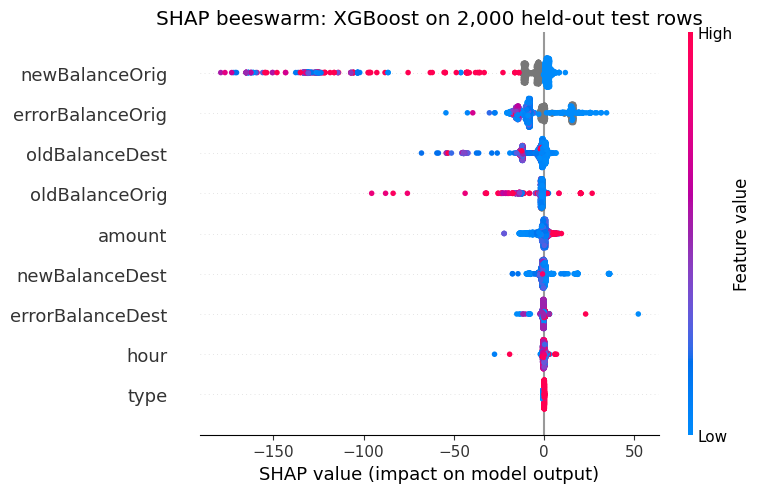

In [55]:
SHAP_SAMPLE_N = CONFIG.get("shap_sample_n", 2_000)
sample_n = min(SHAP_SAMPLE_N, len(X_test))
sample_idx = np.random.RandomState(42).choice(len(X_test), size=sample_n, replace=False)
X_shap = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, plot_type="dot", show=False, max_display=12)
plt.title(f"SHAP beeswarm: XGBoost on {sample_n:,} held-out test rows")
plt.tight_layout(); plt.show()

**Task 13.4:** Explain the five highest-risk test transactions by their three
largest SHAP contributions each.

In [56]:
y_test_scores = predicted_probabilities[:, 1]
top5_idx = np.argsort(-y_test_scores)[:5]
X_top5 = X_test.iloc[top5_idx]
shap_top5 = explainer.shap_values(X_top5)

print("TOP-5 HIGHEST-RISK TEST PREDICTIONS, top-3 SHAP drivers each")
print("=" * 80)
for rank, row_idx in enumerate(top5_idx, start=1):
    prob = y_test_scores[row_idx]
    actual = int(y_test.iloc[row_idx])
    drivers = sorted(zip(X_top5.columns, shap_top5[rank - 1]), key=lambda kv: -abs(kv[1]))[:3]
    print(f"\nTxn #{rank}: fraud_prob={prob:.4f}  actual={'FRAUD' if actual else 'legit'}")
    for feat, contrib in drivers:
        value = float(X_top5[feat].iloc[rank - 1])
        direction = "pushes toward fraud" if contrib > 0 else "pushes toward legit"
        print(f"    {feat:22s} = {value:>15,.2f}  (SHAP {contrib:+.3f}, {direction})")

TOP-5 HIGHEST-RISK TEST PREDICTIONS, top-3 SHAP drivers each

Txn #1: fraud_prob=1.0000  actual=FRAUD
    newBalanceDest         =           -1.00  (SHAP +35.628, pushes toward fraud)
    errorBalanceOrig       =            0.00  (SHAP +31.688, pushes toward fraud)
    oldBalanceOrig         =      383,661.10  (SHAP +8.180, pushes toward fraud)

Txn #2: fraud_prob=1.0000  actual=FRAUD
    newBalanceDest         =           -1.00  (SHAP +36.022, pushes toward fraud)
    oldBalanceOrig         =    4,009,058.39  (SHAP +26.864, pushes toward fraud)
    errorBalanceOrig       =            0.00  (SHAP +19.097, pushes toward fraud)

Txn #3: fraud_prob=1.0000  actual=FRAUD
    errorBalanceOrig       =            0.00  (SHAP +25.360, pushes toward fraud)
    oldBalanceOrig         =    4,009,058.39  (SHAP -10.996, pushes toward legit)
    hour                   =           22.00  (SHAP +7.066, pushes toward fraud)

Txn #4: fraud_prob=1.0000  actual=FRAUD
    newBalanceDest         =           

**Task 13.5:** Rank the features by mean absolute SHAP value, with the
engineered discrepancy features in red.

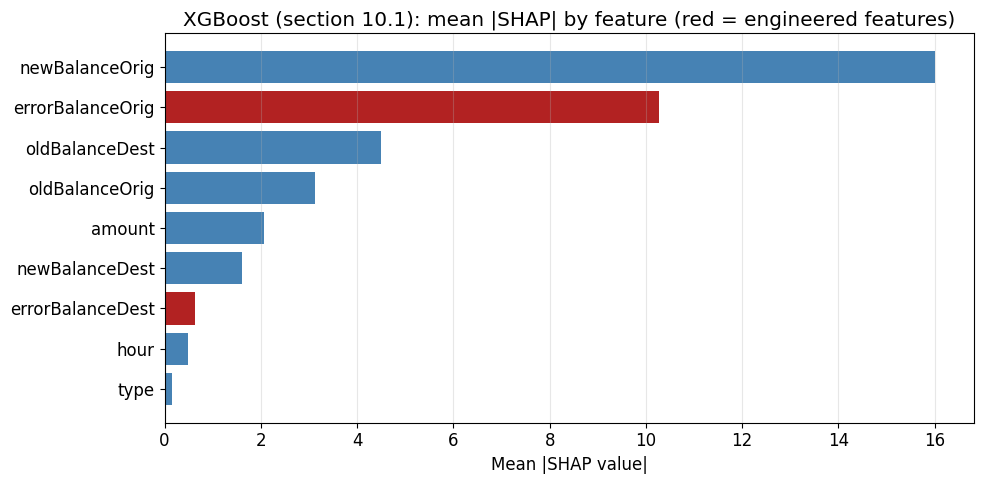

         feature  mean_abs_shap
  newBalanceOrig        16.0154
errorBalanceOrig        10.2632
  oldBalanceDest         4.4982
  oldBalanceOrig         3.1159
          amount         2.0650
  newBalanceDest         1.6062
errorBalanceDest         0.6221
            hour         0.4763
            type         0.1480


In [57]:
all_features = X_test.columns.tolist()
assert len(all_features) == shap_values.shape[1], "one SHAP column per feature"

shap_imp = pd.DataFrame({
    "feature": all_features,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colours = ["firebrick" if f.startswith("error") else "steelblue" for f in shap_imp["feature"]]
ax.barh(shap_imp["feature"], shap_imp["mean_abs_shap"], color=colours)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("XGBoost (section 10.1): mean |SHAP| by feature (red = engineered features)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(shap_imp.sort_values("mean_abs_shap", ascending=False).to_string(index=False))

---
# Part 3: Communicate the results

## 14. Champion and findings

**Task 14.1:** Pick the champion by PR-AUC, excluding the baseline rule. Every
figure printed belongs to the champion itself.

In [58]:
candidates = {k: v for k, v in results.items() if "Baseline" not in k}
champion_name, champion_metrics = max(candidates.items(), key=lambda kv: kv[1]["PR-AUC"])

champion = {
    "name":       champion_name,
    "pr_auc":     champion_metrics["PR-AUC"],
    "roc_auc":    champion_metrics["ROC-AUC"],
    "opt_recall": champion_metrics.get("Recall@99P", 0.0),
}
print("CHAMPION MODEL")
print(f'  Name:                      {champion["name"]}')
print(f'  PR-AUC:                    {champion["pr_auc"]:.4f}')
print(f'  ROC-AUC:                   {champion["roc_auc"]:.4f}')
print(f'  Recall at 99% precision:   {champion["opt_recall"]:.4f}')

CHAMPION MODEL
  Name:                      Random Forest
  PR-AUC:                    1.0000
  ROC-AUC:                   1.0000
  Recall at 99% precision:   1.0000


**What this notebook found.**

1. **The built-in flag is close to useless.** `isFlaggedFraud` catches 16 of
   8,213 frauds (section 3.3), so a model is needed.
2. **Fraud lives in two transaction types.** Keeping only TRANSFER and CASH_OUT
   removes more than half the rows and none of the fraud (section 4).
3. **The ledger gives fraud away.** The destination discrepancy puts fraud and
   genuine transactions on opposite sides of zero (section 7), and the sender
   discrepancy is the most important feature by permutation importance
   (section 11.4). The XGBoost model also leans heavily on the raw sender
   balance (first by SHAP, section 13.2), the "balance hits zero" shortcut the
   shipped pipeline removes (section 15). On PaySim near-perfect scores are
   easy, which is a property of the simulation, not proof of a better model
   (section 11.1).
4. **The threshold is a business decision.** The 99%-precision point and the
   cost-optimal point differ, and the cost ratio has to come from the operator
   (sections 11.2 and 12).
5. **Resampling did not matter here.** SMOTE and class weighting score within
   0.06 points of each other (section 13.1).

## 15. Limitations and future work

**Known limitations of this work.**

1. **No agent-tier features.** In East African mobile-money systems, a registered retail agent layer handles cash-in and cash-out. Agents carry identifiable fraud signatures (velocity spikes, geographic anomalies, concentration in known compromised SIMs). PaySim collapses the agent tier into the `CASH_OUT` type.
2. **No account-age features.** New accounts carry disproportionate fraud risk in real books. PaySim has no account creation timestamps; there is no way to reconstruct this signal from the available columns.
3. **No graph features.** Every transaction is scored in isolation. Mule networks, where A pays B pays C pays D within 24 hours, are a multi-hop pattern that single-transaction scoring misses by construction.
4. **Drift is monitored outside the notebook.** The notebook stores a calibration curve; walk-forward validation and PSI monitoring live in `src/validate.py` and `src/monitoring.py`.
5. **Single holdout evaluation of final threshold.** The 99%-precision threshold is selected on the held-out future window, which is methodologically defensible for a single-shot evaluation but does not test threshold stability across multiple future windows.

**Future work: technical roadmap.**

1. **Graph features over the sender-recipient graph** to capture mule chains.
2. **Concept-drift monitoring.** PSI on the top-5 SHAP features; alert at PSI > 0.2. Retrain trigger at PSI > 0.3 or PR-AUC-drop > 2 pp on a rolling 30-day shadow eval.
3. **Explanations with every score.** SHAP attributions returned alongside the fraud probability, so every block can be explained to the customer and the regulator. The Streamlit dashboard already shows one per scored transaction.
4. **Active-learning loop.** Fraud-ops reviewers label the model's "uncertain" band (scores 0.3-0.7); those labels feed the next retrain.
5. **Cost-sensitive training.** Instead of `scale_pos_weight`, train XGBoost with an asymmetric loss that directly encodes the 10:1 FN:FP cost ratio. The cost-sensitive threshold analysis above is a post-hoc proxy for this; a proper cost-sensitive loss internalises the asymmetry during fitting.

**Where this notebook and `src/` deliberately differ.**

| | This notebook | `src/` (the shipped pipeline) |
|---|---|---|
| Column names | Renamed to camelCase for readability | PaySim's own names, so a Kaggle download needs no pre-processing |
| Feature set | 9 columns, including raw balances and `type` | 5 columns: `amount` plus the four discrepancy/ratio features |
| Raw balances | Kept, to show what they do and do not separate | Dropped: the model was using "balance hits zero" as a shortcut, which also fires on perfectly ordinary account closures |
| Cost ratio | 10:1, swept as the conservative end | 100:1 (1000 vs 10), the shipped operating assumption |
| Threshold | Chosen at a 99% precision floor | Chosen by minimising total cost |

Neither is a correction of the other. The notebook is the wider exploration; the
pipeline is the narrower thing that survived it. The README's headline numbers
come from the pipeline.